In [1]:
!pip install transformers tokenizers seqeval pytorch-crf -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
from torchcrf import CRF
import torch
from transformers import BertModel, AutoModelForTokenClassification, AutoTokenizer, Trainer, TrainingArguments, BertConfig, get_linear_schedule_with_warmup
from torch.optim import AdamW
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from keras.preprocessing.sequence import pad_sequences
from seqeval.metrics import f1_score, accuracy_score
from tqdm import tqdm, trange
import numpy as np
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
log_soft = F.log_softmax

print("All imports successful")

2026-05-27 20:22:18.786234: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779913339.013199      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779913339.080073      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779913339.590668      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779913339.590707      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779913339.590710      58 computation_placer.cc:177] computation placer alr

All imports successful


In [101]:
MAX_LEN = 256
bs = 16

In [30]:
import pickle
import pandas as pd

KG_BASE = '/kaggle/input/datasets/michaelmarkey64/kg-embeddings-baseline-dissertation/'
KG_DIM = 128

# Load TransE embeddings
with open(KG_BASE + 'TransE_qid_embeddings.pkl', 'rb') as f:
    qid_to_embedding = pickle.load(f)

# Build surface form → QID lookup
per = pd.read_csv(KG_BASE + 'per_nodes.csv')
loc = pd.read_csv(KG_BASE + 'loc_nodes.csv')
org = pd.read_csv(KG_BASE + 'org_nodes.csv')
stub = pd.read_csv(KG_BASE + 'stub_nodes.csv')

surface_to_qid = {}

# LOC — entity, canonical, label_ga, label_en + canonicalised variants
for _, row in loc.iterrows():
    if pd.notna(row['entity']) and pd.notna(row['qid']):
        surface_to_qid[row['entity'].strip()] = row['qid']
        surface_to_qid[canonicalise_irish(row['entity'].strip())] = row['qid']
    if pd.notna(row['canonical']) and pd.notna(row['qid']):
        surface_to_qid[row['canonical'].strip()] = row['qid']
        surface_to_qid[canonicalise_irish(row['canonical'].strip())] = row['qid']
    if pd.notna(row['label_ga']) and pd.notna(row['qid']):
        surface_to_qid[row['label_ga'].strip()] = row['qid']
        surface_to_qid[canonicalise_irish(row['label_ga'].strip())] = row['qid']
    if pd.notna(row['label_en']) and pd.notna(row['qid']):
        surface_to_qid[row['label_en'].strip()] = row['qid']

# ORG — entity, canonical, label_ga, label_en + canonicalised variants
for _, row in org.iterrows():
    if pd.notna(row['entity']) and pd.notna(row['qid']):
        surface_to_qid[row['entity'].strip()] = row['qid']
        surface_to_qid[canonicalise_irish(row['entity'].strip())] = row['qid']
    if pd.notna(row['canonical']) and pd.notna(row['qid']):
        surface_to_qid[row['canonical'].strip()] = row['qid']
        surface_to_qid[canonicalise_irish(row['canonical'].strip())] = row['qid']
    if pd.notna(row['label_ga']) and pd.notna(row['qid']):
        surface_to_qid[row['label_ga'].strip()] = row['qid']
        surface_to_qid[canonicalise_irish(row['label_ga'].strip())] = row['qid']
    if pd.notna(row['label_en']) and pd.notna(row['qid']):
        surface_to_qid[row['label_en'].strip()] = row['qid']

# PER — label_ga, label_en, full_name_en + canonicalised variants
for _, row in per.iterrows():
    if pd.notna(row['label_ga']) and pd.notna(row['qid']):
        surface_to_qid[row['label_ga'].strip()] = row['qid']
        surface_to_qid[canonicalise_irish(row['label_ga'].strip())] = row['qid']
    if pd.notna(row['label_en']) and pd.notna(row['qid']):
        surface_to_qid[row['label_en'].strip()] = row['qid']
    if pd.notna(row['full_name_en']) and pd.notna(row['qid']):
        surface_to_qid[row['full_name_en'].strip()] = row['qid']

print(f"Surface form lookup: {len(surface_to_qid)} entries")
print(f"Embeddings loaded: {len(qid_to_embedding)} QIDs")

Surface form lookup: 2315 entries
Embeddings loaded: 1563 QIDs


In [103]:
def read_conll_file(file_path):
    data = []
    current_sentence = []
    with open(file_path, "r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()
            if line.startswith('-DOCSTART-'):
                continue
            if line:
                parts = line.split()
                word = parts[0]
                ner_label = parts[-1]
                current_sentence.append((word, ner_label))
            else:
                if current_sentence:
                    data.append(current_sentence)
                    current_sentence = []
    if current_sentence:
        data.append(current_sentence)
    return data

train_data = read_conll_file('/kaggle/input/datasets/michaelmarkey64/adkins-et-al-2025/train_final.conll')
val_data   = read_conll_file('/kaggle/input/datasets/michaelmarkey64/adkins-et-al-2025/NER_Irish_validation.conll')
test_data  = read_conll_file('/kaggle/input/datasets/michaelmarkey64/adkins-et-al-2025/NER_Irish_test.conll')

print(f"Train sentences: {len(train_data)}")
print(f"Val sentences:   {len(val_data)}")
print(f"Test sentences:  {len(test_data)}")

Train sentences: 1006
Val sentences:   100
Test sentences:  140


In [104]:
def findMWE(sentence):
    tags = [tag for _, tag in sentence]
    if not any(tag.startswith('I-') for tag in tags):
        return False
    prev_tag = None
    for tag in tags:
        if tag.startswith('B-'):
            prev_tag = tag
        elif tag.startswith('I-'):
            if prev_tag and prev_tag[2:] == tag[2:]:
                prev_tag = None
    return prev_tag is None

mwe_test_data = [sentence for sentence in test_data if findMWE(sentence)]
print(f"MWE test sentences: {len(mwe_test_data)}")

MWE test sentences: 89


In [105]:
tokenizer = AutoTokenizer.from_pretrained('DCU-NLP/bert-base-irish-cased-v1', do_lower_case=False)

tag_values = ['O', 'B-PER', 'I-PER', 'B-LOC', 'I-LOC', 'B-ORG', 'I-ORG']
tag_values.append("PAD")
tag2idx = {t: i for i, t in enumerate(tag_values)}

print(f"Tag vocabulary: {tag2idx}")

Tag vocabulary: {'O': 0, 'B-PER': 1, 'I-PER': 2, 'B-LOC': 3, 'I-LOC': 4, 'B-ORG': 5, 'I-ORG': 6, 'PAD': 7}


In [106]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [107]:
def splitWordsAndLabels(data_list):
    sent, labels = [], []
    for lst in data_list:
        s, l = [], []
        for words in lst:
            s.append(words[0])
            l.append(words[1])
        sent.append(s)
        labels.append(l)
    return sent, labels

train_sent, train_labels       = splitWordsAndLabels(train_data)
val_sent, val_labels           = splitWordsAndLabels(val_data)
test_sent, test_labels         = splitWordsAndLabels(test_data)
mwe_test_sent, mwe_test_labels = splitWordsAndLabels(mwe_test_data)

In [108]:
def tokenize_and_preserve_labels(sentence, text_labels):
    tokenized_sentence, labels = [], []
    for word, label in zip(sentence, text_labels):
        tokenized_word = tokenizer.tokenize(word)
        n_subwords = len(tokenized_word)
        tokenized_sentence.extend(tokenized_word)
        labels.extend([label] * n_subwords)
    return tokenized_sentence, labels

tokenized_texts_and_labels = [
    tokenize_and_preserve_labels(sent, labs)
    for sent, labs in zip(train_sent, train_labels)
]
val_tokenized_texts_and_labels = [
    tokenize_and_preserve_labels(sent, labs)
    for sent, labs in zip(val_sent, val_labels)
]
test_tokenized_texts_and_labels = [
    tokenize_and_preserve_labels(sent, labs)
    for sent, labs in zip(test_sent, test_labels)
]
mwe_test_tokenized_texts_and_labels = [
    tokenize_and_preserve_labels(sent, labs)
    for sent, labs in zip(mwe_test_sent, mwe_test_labels)
]

tokenized_texts       = [p[0] for p in tokenized_texts_and_labels]
tokenized_labels      = [p[1] for p in tokenized_texts_and_labels]
val_tokenized_texts   = [p[0] for p in val_tokenized_texts_and_labels]
val_tokenized_labels  = [p[1] for p in val_tokenized_texts_and_labels]
test_tokenized_texts  = [p[0] for p in test_tokenized_texts_and_labels]
test_tokenized_labels = [p[1] for p in test_tokenized_texts_and_labels]
mwe_test_tokenized_texts  = [p[0] for p in mwe_test_tokenized_texts_and_labels]
mwe_tokenized_labels      = [p[1] for p in mwe_test_tokenized_texts_and_labels]

print(f"Sample tokenized: {tokenized_texts[0][:10]}")

Sample tokenized: ['Dáil', 'Éireann', '06', '/', '07', '/', '2023']


In [109]:
import numpy as np

def get_kg_embedding(span):
    qid = surface_to_qid.get(span.strip())
    if qid and qid in qid_to_embedding:
        return qid_to_embedding[qid]
    return np.zeros(KG_DIM, dtype=np.float32)

def build_entity_ids(tokenized_texts_and_labels_list):
    # For each sentence, for each token, look up KG embedding by entity span
    # Uses gold IOB2 labels to identify spans (Option B)
    all_entity_embeddings = []
    for tokens, labels in tokenized_texts_and_labels_list:
        token_embeddings = []
        i = 0
        while i < len(tokens):
            label = labels[i]
            if label.startswith('B-'):
                # Collect full span
                span_tokens = [tokens[i]]
                j = i + 1
                while j < len(labels) and labels[j].startswith('I-'):
                    span_tokens.append(tokens[j])
                    j += 1
                # Reconstruct span string (remove ## subword markers)
                span = ''.join(t[2:] if t.startswith('##') else ' ' + t for t in span_tokens).strip()
                emb = get_kg_embedding(span)
                for _ in span_tokens:
                    token_embeddings.append(emb)
                i = j
            else:
                token_embeddings.append(np.zeros(KG_DIM, dtype=np.float32))
                i += 1
        all_entity_embeddings.append(token_embeddings)
    return all_entity_embeddings

def pad_embeddings(embedding_lists, max_len, kg_dim):
    result = np.zeros((len(embedding_lists), max_len, kg_dim), dtype=np.float32)
    for i, emb_list in enumerate(embedding_lists):
        length = min(len(emb_list), max_len)
        result[i, :length, :] = emb_list[:length]
    return result

# --- Original Cell 10 content below ---

input_ids = pad_sequences(
    [tokenizer.convert_tokens_to_ids(txt) for txt in tokenized_texts],
    maxlen=MAX_LEN, dtype="long", value=0.0, truncating="post", padding="post")
val_input_ids = pad_sequences(
    [tokenizer.convert_tokens_to_ids(txt) for txt in val_tokenized_texts],
    maxlen=MAX_LEN, dtype="long", value=0.0, truncating="post", padding="post")
test_input_ids = pad_sequences(
    [tokenizer.convert_tokens_to_ids(txt) for txt in test_tokenized_texts],
    maxlen=MAX_LEN, dtype="long", value=0.0, truncating="post", padding="post")
mwe_test_input_ids = pad_sequences(
    [tokenizer.convert_tokens_to_ids(txt) for txt in mwe_test_tokenized_texts],
    maxlen=MAX_LEN, dtype="long", value=0.0, truncating="post", padding="post")

tags = pad_sequences(
    [[tag2idx.get(l) for l in lab] for lab in tokenized_labels],
    maxlen=MAX_LEN, value=tag2idx["PAD"], padding="post", dtype="long", truncating="post")
val_tags = pad_sequences(
    [[tag2idx.get(l) for l in lab] for lab in val_tokenized_labels],
    maxlen=MAX_LEN, value=tag2idx["PAD"], padding="post", dtype="long", truncating="post")
test_tags = pad_sequences(
    [[tag2idx.get(l) for l in lab] for lab in test_tokenized_labels],
    maxlen=MAX_LEN, value=tag2idx["PAD"], padding="post", dtype="long", truncating="post")
mwe_test_tags = pad_sequences(
    [[tag2idx.get(l) for l in lab] for lab in mwe_tokenized_labels],
    maxlen=MAX_LEN, value=tag2idx["PAD"], padding="post", dtype="long", truncating="post")

attention_masks         = [[float(i != 0.0) for i in ii] for ii in input_ids]
val_attention_masks     = [[float(i != 0.0) for i in ii] for ii in val_input_ids]
test_attention_masks    = [[float(i != 0.0) for i in ii] for ii in test_input_ids]
mwe_test_attention_masks = [[float(i != 0.0) for i in ii] for ii in mwe_test_input_ids]

# Build KG embedding tensors
train_kg = pad_embeddings(build_entity_ids(tokenized_texts_and_labels), MAX_LEN, KG_DIM)
val_kg   = pad_embeddings(build_entity_ids(val_tokenized_texts_and_labels), MAX_LEN, KG_DIM)
test_kg  = pad_embeddings(build_entity_ids(test_tokenized_texts_and_labels), MAX_LEN, KG_DIM)
mwe_test_kg = pad_embeddings(build_entity_ids(mwe_test_tokenized_texts_and_labels), MAX_LEN, KG_DIM)

# Count non-zero embeddings (coverage check)
nonzero = np.any(train_kg != 0, axis=-1).sum()
total   = (train_kg.shape[0] * train_kg.shape[1])
print(f"KG coverage: {nonzero}/{total} token positions have non-zero embeddings ({100*nonzero/total:.2f}%)")

tr_inputs  = torch.tensor(input_ids);      tr_tags  = torch.tensor(tags);      tr_masks  = torch.tensor(attention_masks)
vl_inputs  = torch.tensor(val_input_ids);  vl_tags  = torch.tensor(val_tags);  vl_masks  = torch.tensor(val_attention_masks)
tst_inputs = torch.tensor(test_input_ids); tst_tags = torch.tensor(test_tags); tst_masks = torch.tensor(test_attention_masks)
mwe_tst_inputs = torch.tensor(mwe_test_input_ids); mwe_tst_tags = torch.tensor(mwe_test_tags); mwe_tst_masks = torch.tensor(mwe_test_attention_masks)

tr_kg_tensor      = torch.tensor(train_kg)
vl_kg_tensor      = torch.tensor(val_kg)
tst_kg_tensor     = torch.tensor(test_kg)
mwe_tst_kg_tensor = torch.tensor(mwe_test_kg)

tr_data   = TensorDataset(tr_inputs, tr_masks, tr_tags, tr_kg_tensor)
train_dataloader = DataLoader(tr_data, sampler=RandomSampler(tr_data), batch_size=bs)
valid_data = TensorDataset(vl_inputs, vl_masks, vl_tags, vl_kg_tensor)
valid_dataloader = DataLoader(valid_data, sampler=SequentialSampler(valid_data), batch_size=bs)
tst_data  = TensorDataset(tst_inputs, tst_masks, tst_tags, tst_kg_tensor)
tst_dataloader = DataLoader(tst_data, sampler=SequentialSampler(tst_data), batch_size=bs)
mwe_tst_data = TensorDataset(mwe_tst_inputs, mwe_tst_masks, mwe_tst_tags, mwe_tst_kg_tensor)
mwe_tst_dataloader = DataLoader(mwe_tst_data, sampler=SequentialSampler(mwe_tst_data), batch_size=bs)

print("Dataloaders ready")

KG coverage: 619/257536 token positions have non-zero embeddings (0.24%)
Dataloaders ready


In [113]:
config = BertConfig.from_pretrained('DCU-NLP/bert-base-irish-cased-v1', output_hidden_states=True)
config.max_position_embeddings = 512

bert_model = BertModel.from_pretrained(
    'DCU-NLP/bert-base-irish-cased-v1',
    config=config,
    add_pooling_layer=False
)
print("gaBERT loaded")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: DCU-NLP/bert-base-irish-cased-v1
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
bert.pooler.dense.weight                   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.pooler.dense.bias                     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/a

gaBERT loaded


In [114]:
class BERT_KG_CRF(nn.Module):
    def __init__(self, bert_model, num_labels, kg_dim=128):
        super(BERT_KG_CRF, self).__init__()
        self.bert = bert_model
        self.dropout = nn.Dropout(0.25)
        self.classifier = nn.Linear(4*768 + kg_dim, num_labels)
        self.crf = CRF(num_labels, batch_first=True)

    def forward_custom(self, b_input_ids, b_input_mask, b_kg_embeds, b_labels=None, token_type_ids=None):
        outputs = self.bert(b_input_ids, attention_mask=b_input_mask)
        sequence_output = torch.cat((outputs[1][-1], outputs[1][-2], outputs[1][-3], outputs[1][-4]), -1)
        b_kg_embeds = b_kg_embeds.to(sequence_output.dtype)
        sequence_output = torch.cat([sequence_output, b_kg_embeds], dim=-1)
        sequence_output = self.dropout(sequence_output)
        emission = self.classifier(sequence_output)

        if b_labels is not None:
            loss = -self.crf(log_soft(emission, 2), b_labels, mask=b_input_mask.type(torch.uint8), reduction='mean')
            prediction = self.crf.decode(emission, mask=b_input_mask.type(torch.uint8))
            return [loss, prediction]
        else:
            prediction = self.crf.decode(emission, mask=b_input_mask.type(torch.uint8))
            return prediction

model = BERT_KG_CRF(bert_model, num_labels=len(tag2idx))
model.to(device)
print("Model ready")

Model ready


In [115]:
FINETUNING = True
cnt = -1
num_layer = 197

param_optimizer1 = list(model.named_parameters())[:num_layer]
param_optimizer2 = list(model.named_parameters())[num_layer:num_layer+2]
param_optimizer3 = list(model.named_parameters())[num_layer+2:]
no_decay = ['bias', 'gamma', 'beta']

optimizer_grouped_parameters = [
    {'params': [p for n, p in param_optimizer1 if not any(nd in n for nd in no_decay)], 'weight_decay_rate': 1e-5},
    {'params': [p for n, p in param_optimizer1 if any(nd in n for nd in no_decay)], 'weight_decay_rate': 0.0},
    {'params': [p for n, p in param_optimizer2 if not any(nd in n for nd in no_decay)], 'weight_decay_rate': 1e-3, 'lr': 1e-3},
    {'params': [p for n, p in param_optimizer2 if any(nd in n for nd in no_decay)], 'weight_decay_rate': 0.0, 'lr': 1e-3},
    {'params': [p for n, p in param_optimizer3 if not any(nd in n for nd in no_decay)], 'weight_decay_rate': 1e-3, 'lr': 4e-3},
    {'params': [p for n, p in param_optimizer3 if any(nd in n for nd in no_decay)], 'weight_decay_rate': 0.0, 'lr': 4e-3}
]

optimizer = AdamW(optimizer_grouped_parameters, lr=3e-5, eps=1e-8)
epochs = 10
max_grad_norm = 1.0
total_steps = len(train_dataloader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(total_steps/10), num_training_steps=total_steps)
print("Optimiser ready")

Optimiser ready


In [116]:
## Store the average loss after each epoch so we can plot them

epochs = 10
loss_values, validation_loss_values = [], []
best_model_state = None
patience = 2
best_val_loss = float('inf')
epochs_without_improvement = 0
best_epoch = 0

for epoch in trange(epochs, desc="Epoch"):
    # ========================================
    #               Training
    # ========================================
    model.train()
    total_loss = 0

    for step, batch in enumerate(train_dataloader):
        batch = tuple(t.to(device) for t in batch)
        b_input_ids, b_input_mask, b_labels, b_kg_embeds = batch
        b_kg_embeds = b_kg_embeds.to(device)
        model.zero_grad()
        outputs = model.forward_custom(b_input_ids, b_input_mask, b_kg_embeds, b_labels, token_type_ids=None)
        loss = outputs[0]
        loss.backward()
        total_loss += loss.item()
        torch.nn.utils.clip_grad_norm_(parameters=model.parameters(), max_norm=max_grad_norm)
        optimizer.step()
        scheduler.step()

    avg_train_loss = total_loss / len(train_dataloader)
    print("Average train loss: {}".format(avg_train_loss))
    loss_values.append(avg_train_loss)

    # ========================================
    #               Validation
    # ========================================
    model.eval()
    eval_loss, eval_accuracy = 0, 0
    nb_eval_steps, nb_eval_examples = 0, 0
    predictions, true_labels = [], []

    for batch in valid_dataloader:
        batch = tuple(t.to(device) for t in batch)
        b_input_ids, b_input_mask, b_labels, b_kg_embeds = batch
        b_kg_embeds = b_kg_embeds.to(device)

        with torch.no_grad():
            outputs = model.forward_custom(b_input_ids, b_input_mask, b_kg_embeds, b_labels, token_type_ids=None)

        logits = outputs[0].detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()
        eval_loss += outputs[0].mean().item()
        predictions.extend(outputs[1])
        true_labels.extend(label_ids)

    eval_loss = eval_loss / len(valid_dataloader)
    validation_loss_values.append(eval_loss)
    print("Validation loss: {}".format(eval_loss))

    pred_tags = []
    valid_tags = []
    for p, l in zip(predictions, true_labels):
        for p_i, l_i in zip(p, l):
            if tag_values[l_i] != "PAD":
                pred_tags.append(tag_values[p_i])
                valid_tags.append(tag_values[l_i])
                tokens = tokenizer.convert_ids_to_tokens(b_input_ids[0].to('cpu').numpy())
                new_tokens, new_labels, new_preds = [], [], []
                for token, label_idx, pred in zip(tokens, l, p):
                    if token.startswith("##"):
                        new_tokens[-1] = new_tokens[-1] + token[2:]
                    else:
                        new_labels.append(label_idx)
                        new_preds.append(pred)
                        new_tokens.append(token)
                for token, pred, label in zip(new_tokens, new_preds, new_labels):
                    pred_tags.append(tag_values[pred])
                    valid_tags.append(tag_values[label])

    print("Validation Accuracy: {}".format(accuracy_score(pred_tags, valid_tags)))
    val_report = classification_report(valid_tags, pred_tags)
    print("Epoch {} - Validation Classification Report:".format(epoch))
    print(val_report)

    if eval_loss < best_val_loss:
        best_val_loss = eval_loss
        best_epoch = epoch
        best_model_state = model.state_dict()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Validation loss hasn't improved for {patience} epochs. Best model found at epoch {best_epoch}.")
            break

    print("Epoch {} - Training Loss: {:.4f}, Validation Loss: {:.4f}".format(epoch, avg_train_loss, eval_loss))
    print()

if best_model_state is not None:
    torch.save(best_model_state, "gaBERT_KG_CRF.pt")

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Average train loss: 25.577792213076638
Validation loss: 5.950860704694476
Validation Accuracy: 0.9383931544731927


Epoch:  10%|█         | 1/10 [01:09<10:22, 69.13s/it]

Epoch 0 - Validation Classification Report:
              precision    recall  f1-score   support

       B-LOC       0.84      0.85      0.84      2563
       B-ORG       0.65      0.76      0.70      4166
       B-PER       0.78      0.65      0.71      3450
       I-LOC       0.91      0.86      0.88      1681
       I-ORG       0.61      0.70      0.65      4941
       I-PER       0.78      0.70      0.74      6028
           O       0.98      0.98      0.98    115305

    accuracy                           0.94    138134
   macro avg       0.79      0.79      0.79    138134
weighted avg       0.94      0.94      0.94    138134

Epoch 0 - Training Loss: 25.5778, Validation Loss: 5.9509

Average train loss: 5.185180611080593
Validation loss: 5.156567505427769
Validation Accuracy: 0.9468559514674157


Epoch:  20%|██        | 2/10 [02:17<09:07, 68.40s/it]

...

Epoch 2 - Validation Classification Report:
              precision    recall  f1-score   support

       B-LOC       0.91      0.92      0.92      2563
       B-ORG       0.76      0.78      0.77      4166
       B-PER       0.85      0.77      0.81      3450
       I-LOC       0.79      0.98      0.88      1681
       I-ORG       0.61      0.81      0.69      4941
       I-PER       0.87      0.72      0.79      6028
           O       0.99      0.98      0.98    115305

    accuracy                           0.95    138134
   macro avg       0.83      0.85      0.83    138134
weighted avg       0.96      0.95      0.95    138134

Epoch 2 - Training Loss: 2.1892, Validation Loss: 5.0156

Average train loss: 1.054941255658392
Validation loss: 5.896933419363839
Validation Accuracy: 0.9475798861974605


Epoch:  40%|████      | 4/10 [04:33<06:49, 68.31s/it]

Epoch 3 - Validation Classification Report:
              precision    recall  f1-score   support

       B-LOC       0.85      0.83      0.84      2563
       B-ORG       0.66      0.79      0.72      4166
       B-PER       0.80      0.74      0.77      3450
       I-LOC       0.78      0.95      0.86      1681
       I-ORG       0.65      0.91      0.76      4941
       I-PER       0.90      0.73      0.80      6028
           O       0.99      0.98      0.98    115305

    accuracy                           0.95    138134
   macro avg       0.80      0.85      0.82    138134
weighted avg       0.95      0.95      0.95    138134

Epoch 3 - Training Loss: 1.0549, Validation Loss: 5.8969

Average train loss: 0.5715479098615193
Validation loss: 7.031084060668945
Validation Accuracy: 0.9496503395253884


Epoch:  40%|████      | 4/10 [05:41<08:32, 85.40s/it]

Epoch 4 - Validation Classification Report:
              precision    recall  f1-score   support

       B-LOC       0.86      0.88      0.87      2563
       B-ORG       0.70      0.80      0.74      4166
       B-PER       0.85      0.74      0.79      3450
       I-LOC       0.79      0.97      0.87      1681
       I-ORG       0.63      0.80      0.71      4941
       I-PER       0.83      0.75      0.79      6028
           O       0.99      0.98      0.99    115305

    accuracy                           0.95    138134
   macro avg       0.81      0.84      0.82    138134
weighted avg       0.95      0.95      0.95    138134

Validation loss hasn't improved for 2 epochs. Best model found at epoch 2.


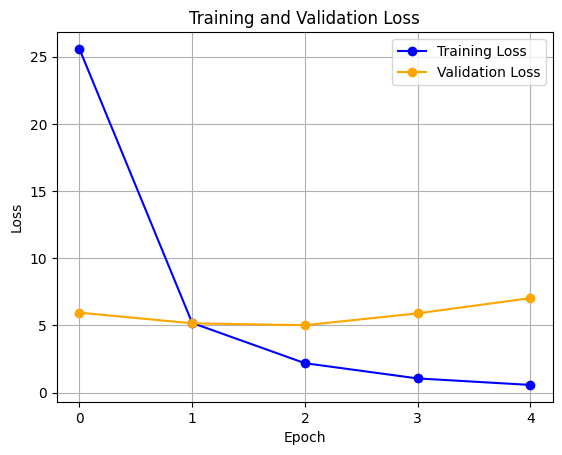

In [117]:
# Training and Validation Loss Plot

# Generate x-axis values (epochs)
epochs = range(len(loss_values) + 1)

# Plotting with markers and lines
plt.plot(epochs[:-1], loss_values, marker='o', linestyle='-', label='Training Loss', color='blue')
plt.plot(epochs[:-1], validation_loss_values, marker='o', linestyle='-', label='Validation Loss', color='orange')

# Labeling and styling
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Set ticks for x-axis (epochs) to whole numbers only starting from 0
plt.xticks(epochs[:-1])


# Ensure y-axis (loss) ticks are whole numbers only
#plt.yticks(range(int(min(min(loss_values), min(validation_loss_values))), int(max(max(loss_values), max(validation_loss_values))) + 1))
plt.savefig('gabert_RDA_CRF_training_validation_loss_plot.png')
# Show plot
plt.grid(True)
plt.show()

In [124]:
model.eval()
predicted_labels = []
true_labels = []

for batch in tst_dataloader:
    batch = tuple(t.to(device) for t in batch)
    b_input_ids, b_input_mask, b_labels, b_kg_embeds = batch
    b_kg_embeds = b_kg_embeds.to(device)

    with torch.no_grad():
        outputs = model.forward_custom(b_input_ids, b_input_mask, b_kg_embeds, b_labels, token_type_ids=None)

    predict_labels = outputs[1]
    for predict_label in predict_labels:
        predicted_labels.append(predict_label)

    true_labels.extend(b_labels.tolist())

In [125]:
trues = []

for sentences in true_labels:
  t = []
  for vals in sentences:
    if vals != 7:
      t.append(vals)
  trues.append(t)

preds=predicted_labels

In [128]:
label_map = {
    0: 'O',
    1: 'B-PER',
    2: 'I-PER',
    3: 'B-LOC',
    4: 'I-LOC',
    5: 'B-ORG',
    6: 'I-ORG'
}

# Initialise an empty list to store DataFrames
dfs = []

# Iterate through the tokens, labels, and predictions
for tokens, labels, predictions in zip(test_tokenized_texts, test_tokenized_labels, preds):
    temp_df = pd.DataFrame({'Word': tokens, 'POS': 'X', 'True': labels, 'Predicted': [label_map[pred] for pred in predictions]})
    dfs.append(temp_df)
    dfs.append(pd.DataFrame({'Word': [''], 'POS': [''], 'True': [''], 'Predicted': ['']}))

df = pd.concat(dfs, ignore_index=True)
print(df)
print(df.head(45))

           Word POS   True Predicted
0           Mar   X      O         O
1             a   X      O         O
2             t   X      O         O
3          ##ch   X      O         O
4       ##ítear   X      O         O
...         ...  ..    ...       ...
4839          a   X      O         O
4840     bhfuil   X      O         O
4841  Gaeltacht   X  B-LOC     B-LOC
4842        ann   X      O         O
4843                                

[4844 rows x 4 columns]
           Word POS   True Predicted
0           Mar   X      O         O
1             a   X      O         O
2             t   X      O         O
3          ##ch   X      O         O
4       ##ítear   X      O         O
5            do   X      O         O
6         Sheos   X  B-PER     B-PER
7         ##amh   X  B-PER     B-PER
8           Mac   X  I-PER     I-PER
9       Grianna   X  I-PER     I-PER
10            é   X      O         O
11    caithfidh   X      O         O
12           an   X      O         O
13           

In [129]:
# Change to conll format for evaluation script to be run
conll_format = ""

for index, row in df.iterrows():
    text = row['Word']
    pos = row['POS']
    tag = row['True']
    mapped_tag = row['Predicted']

    # Append the token in CoNLL format (word, POS, gold_label, predicted_label)
    conll_format += f"{text}\t{pos}\t{tag}\t{mapped_tag}\n"

# Write the CoNLL format string to a text file
with open('gaBERT_RDA_CRF.conll', 'w') as f:
    f.write(conll_format)

In [132]:
model.eval()
mwe_predicted_labels = []
mwe_true_labels = []

for batch in mwe_tst_dataloader:
    batch = tuple(t.to(device) for t in batch)
    b_input_ids, b_input_mask, b_labels, b_kg_embeds = batch
    b_kg_embeds = b_kg_embeds.to(device)

    with torch.no_grad():
        outputs = model.forward_custom(b_input_ids, b_input_mask, b_kg_embeds, b_labels, token_type_ids=None)

    predict_labels = outputs[1]
    for predict_label in predict_labels:
        mwe_predicted_labels.append(predict_label)

    mwe_true_labels.extend(b_labels.tolist())

In [136]:
mwe_preds = []
mwe_trues = []

for sentences in mwe_true_labels:
  t = []
  for vals in sentences:
    if vals != 7:
      t.append(vals)
  mwe_trues.append(t)

for sentences in mwe_predicted_labels:
  p = []
  for vals in sentences:
    if vals != 7:
      p.append(vals)
  mwe_preds.append(p)


#print(mwe_test_tokenized_texts_and_labels)
mwe_tokenized_labels = []
for sentence, labels in mwe_test_tokenized_texts_and_labels:
    mwe_tokenized_labels.append(labels)

print(len(mwe_test_tokenized_texts[0]))
print(len(mwe_trues[0]))
print(len(mwe_tokenized_labels[0]))
print(len(mwe_preds[0]))

39
39
39
39


In [139]:
# Initialise an empty list to store DataFrames
dfs = []

# Iterate through the tokens, labels, and predictions
for tokens, labels, predictions in zip(mwe_test_tokenized_texts, mwe_tokenized_labels, mwe_preds):
    # Create a DataFrame from the current sublist
    temp_df = pd.DataFrame({'Word': tokens, 'POS': 'X', 'True': labels, 'Predicted': [label_map[pred] for pred in predictions]})
    # Append the DataFrame to the list
    dfs.append(temp_df)
    # Add an empty row as a DataFrame to the list
    dfs.append(pd.DataFrame({'Word': [''], 'POS': [''], 'True': [''], 'Predicted': ['']}))

# Concatenate the DataFrames along the rows axis
df = pd.concat(dfs, ignore_index=True)

# Print the concatenated DataFrame
print(df)

# Check the alignment is correct
print(df.head(45))

         Word POS   True Predicted
0         Mar   X      O         O
1           a   X      O         O
2           t   X      O         O
3        ##ch   X      O         O
4     ##ítear   X      O         O
...       ...  ..    ...       ...
3167       na   X  I-LOC     I-LOC
3168       nD   X  I-LOC     I-LOC
3169   ##éise   X  I-LOC     I-LOC
3170        .   X      O         O
3171                              

[3172 rows x 4 columns]
           Word POS   True Predicted
0           Mar   X      O         O
1             a   X      O         O
2             t   X      O         O
3          ##ch   X      O         O
4       ##ítear   X      O         O
5            do   X      O         O
6         Sheos   X  B-PER     B-PER
7         ##amh   X  B-PER     B-PER
8           Mac   X  I-PER     I-PER
9       Grianna   X  I-PER     I-PER
10            é   X      O         O
11    caithfidh   X      O         O
12           an   X      O         O
13            t   X      O         O


In [140]:
# Change to conll format for evaluation script to be run
conll_format = ""

for index, row in df.iterrows():
    text = row['Word']
    pos = row['POS']
    tag = row['True']
    mapped_tag = row['Predicted']

    # Append the token in CoNLL format (word, POS, gold_label, predicted_label)
    conll_format += f"{text}\t{pos}\t{tag}\t{mapped_tag}\n"

# Write the CoNLL format string to a text file
with open('gaBERT_RDA_CRF_MWE.conll', 'w') as f:
    f.write(conll_format)

In [141]:
!pip install conlleval
from conlleval import evaluate

with open('gaBERT_RDA_CRF.conll') as f:
    lines = f.read().splitlines()

evaluate(lines)

{'overall': {'chunks': {'stats': {'gold': 469, 'pred': 488, 'correct': 372},
   'evals': {'f1': 0.7774294670846396,
    'prec': 0.7622950819672131,
    'rec': 0.7931769722814499}},
  'tags': {'stats': {'gold': 4704, 'pred': 4704, 'correct': 4470},
   'evals': {'f1': 0.9502551020408163,
    'prec': 0.9502551020408163,
    'rec': 0.9502551020408163}}},
 'slots': {'chunks': {'LOC': {'stats': {'gold': 169,
     'pred': 175,
     'correct': 134},
    'evals': {'f1': 0.7790697674418605,
     'prec': 0.7657142857142857,
     'rec': 0.7928994082840237}},
   'ORG': {'stats': {'gold': 136, 'pred': 153, 'correct': 102},
    'evals': {'f1': 0.7058823529411765,
     'prec': 0.6666666666666666,
     'rec': 0.75}},
   'PER': {'stats': {'gold': 164, 'pred': 160, 'correct': 136},
    'evals': {'f1': 0.8395061728395061,
     'prec': 0.85,
     'rec': 0.8292682926829268}}},
  'tags': {'LOC': {'stats': {'gold': 336, 'pred': 331, 'correct': 278},
    'evals': {'f1': 0.8335832083958019,
     'prec': 0.83987

In [143]:
from conlleval import evaluate

with open('gaBERT_RDA_CRF_MWE.conll') as f:
    lines = f.read().splitlines()

evaluate(lines)

{'overall': {'chunks': {'stats': {'gold': 268, 'pred': 300, 'correct': 222},
   'evals': {'f1': 0.7816901408450704,
    'prec': 0.74,
    'rec': 0.8283582089552238}},
  'tags': {'stats': {'gold': 3083, 'pred': 3083, 'correct': 2937},
   'evals': {'f1': 0.9526435290301655,
    'prec': 0.9526435290301655,
    'rec': 0.9526435290301655}}},
 'slots': {'chunks': {'LOC': {'stats': {'gold': 85, 'pred': 95, 'correct': 68},
    'evals': {'f1': 0.7555555555555556,
     'prec': 0.7157894736842105,
     'rec': 0.8}},
   'ORG': {'stats': {'gold': 77, 'pred': 101, 'correct': 64},
    'evals': {'f1': 0.7191011235955057,
     'prec': 0.6336633663366337,
     'rec': 0.8311688311688312}},
   'PER': {'stats': {'gold': 106, 'pred': 104, 'correct': 90},
    'evals': {'f1': 0.8571428571428571,
     'prec': 0.8653846153846154,
     'rec': 0.8490566037735849}}},
  'tags': {'LOC': {'stats': {'gold': 188, 'pred': 198, 'correct': 158},
    'evals': {'f1': 0.8186528497409327,
     'prec': 0.797979797979798,
     

---

## Phase 3 — Run 2: Augmented Knowledge Graph

**Date:** 29 May 2026

**Baseline result (Run 1):**
- Mixed-length test F1: 0.777
- MWE test F1: 0.782

**Changes in this run:**
- Morphological canonicalisation added to surface form lookup (Irish lenition/eclipsis stripping)
- Logainm integration for LOC nodes (Irish placenames database, via P6872 Wikidata cross-reference)
- Oireachtas API PER matches loaded (65 confirmed politicians with constituency and committee edges)
- Richer LOCATED_IN hierarchy from Logainm parent IDs

**Hypothesis:** Improved KG coverage and richer LOC hierarchy will improve overall F1, particularly for LOC and ORG entity classes where coverage was weakest in Run 1.

In [26]:
def canonicalise_irish(surface_form):
    s = surface_form.strip()
    
    # Normalise curly apostrophes to straight
    s = s.replace('\u2019', "'").replace('\u2018', "'")

    # Strip leading Irish definite articles
    for article in ('an t-', 'na h-', 'an ', 'na '):
        if s.lower().startswith(article.lower()):
            s = s[len(article):].strip()
            break

    # Strip t- before vowel (an tOireachtas → tOireachtas → Oireachtas)
    if len(s) > 1 and s[0] == 't' and s[1].isupper():
        s = s[1:]

    # Handle eclipsis prefixes (must check before lenition)
    # Eclipsis: mb→B, gc→C, nd→D, bhf→F, ng→G, bp→P, dt→T
    eclipsis_map = {
        'mb': 'B', 'gc': 'C', 'nd': 'D',
        'bhf': 'F', 'ng': 'G', 'bp': 'P', 'dt': 'T',
        'mB': 'B', 'gC': 'C', 'nD': 'D',
        'bhF': 'F', 'nG': 'G', 'bP': 'P', 'dT': 'T'
    }
    for prefix, canonical_initial in eclipsis_map.items():
        if s.startswith(prefix):
            remainder = s[len(prefix):]
            return canonical_initial + remainder

    # Handle vowel eclipsis: n- prefix before vowels
    if len(s) > 2 and s[0] == 'n' and s[1] == '-':
        return s[2:].capitalize()
    if len(s) > 1 and s[0] == 'n' and s[1].isupper():
        return s[1:]

    # Handle h- prefix before vowels: hÉireann → Éireann
    if len(s) > 1 and s[0] == 'h' and s[1].isupper():
        return s[1:]
    if len(s) > 2 and s[:2] == 'h-':
        return s[2:].capitalize()

    # Handle lenition: consonant + h → consonant
    lenition_map = {
        'Bh': 'B', 'Ch': 'C', 'Dh': 'D', 'Fh': 'F',
        'Gh': 'G', 'Mh': 'M', 'Ph': 'P', 'Sh': 'S', 'Th': 'T',
        'bh': 'b', 'ch': 'c', 'dh': 'd', 'fh': 'f',
        'gh': 'g', 'mh': 'm', 'ph': 'p', 'sh': 's', 'th': 't'
    }
    for prefix, canonical_initial in lenition_map.items():
        if s.startswith(prefix) and len(s) > 2:
            remainder = s[len(prefix):]
            return canonical_initial + remainder

    # Handle genitive article stripping
    # d' before vowels: d'Údarás → Údarás
    if len(s) > 2 and s[:2] == "d'" and s[2].isupper():
        return s[2:]

    return s  # no mutation detected, return as-is

# Test against known cases from your log
test_cases = [
    ('Chomhairle Cathrach Bhaile Átha Cliath', 'Comhairle Cathrach Bhaile Átha Cliath'),
    ('Pharlaimint na hEorpa', 'Parlaimint na hEorpa'),
    ('Chonradh na Gaeilge', 'Conradh na Gaeilge'),
    ('mBaile Átha Cliath', 'Baile Átha Cliath'),
    ('gCeathrú Rua', 'Ceathrú Rua'),
    ('nGaoth Dobhair', 'Gaoth Dobhair'),
    ("d'Údarás na Gaeltachta", 'Údarás na Gaeltachta'),
    ('hÉireann', 'Éireann'),
    ('Aontais Eorpaigh', 'Aontais Eorpaigh'),  # genitive, not mutation — should return as-is
]

print("Canonicalisation test results:")
for surface, expected in test_cases:
    result = canonicalise_irish(surface)
    status = '✓' if result == expected else '✗'
    print(f"{status} '{surface}' → '{result}' (expected '{expected}')")

Canonicalisation test results:
✓ 'Chomhairle Cathrach Bhaile Átha Cliath' → 'Comhairle Cathrach Bhaile Átha Cliath' (expected 'Comhairle Cathrach Bhaile Átha Cliath')
✓ 'Pharlaimint na hEorpa' → 'Parlaimint na hEorpa' (expected 'Parlaimint na hEorpa')
✓ 'Chonradh na Gaeilge' → 'Conradh na Gaeilge' (expected 'Conradh na Gaeilge')
✓ 'mBaile Átha Cliath' → 'Baile Átha Cliath' (expected 'Baile Átha Cliath')
✓ 'gCeathrú Rua' → 'Ceathrú Rua' (expected 'Ceathrú Rua')
✓ 'nGaoth Dobhair' → 'Gaoth Dobhair' (expected 'Gaoth Dobhair')
✓ 'd'Údarás na Gaeltachta' → 'Údarás na Gaeltachta' (expected 'Údarás na Gaeltachta')
✓ 'hÉireann' → 'Éireann' (expected 'Éireann')
✓ 'Aontais Eorpaigh' → 'Aontais Eorpaigh' (expected 'Aontais Eorpaigh')


In [ ]:
import pickle
import pandas as pd

KG3_BASE = '/kaggle/input/datasets/michaelmarkey64/kg-embeddings-phase3/'
KG_DIM = 128

# Load Phase 3 TransE embeddings
with open(KG3_BASE + 'TransE_qid_embeddings.pkl', 'rb') as f:
    qid_to_embedding = pickle.load(f)

print(f"Phase 3 embeddings loaded: {len(qid_to_embedding)} entities")
print(f"Sample keys: {list(qid_to_embedding.keys())[:5]}")
print(f"Embedding shape: {list(qid_to_embedding.values())[0].shape}")

# Load Phase 3 node CSVs
per = pd.read_csv(KG3_BASE + 'per_nodes.csv')
loc = pd.read_csv(KG3_BASE + 'loc_nodes.csv')
org = pd.read_csv(KG3_BASE + 'org_nodes.csv')
stub = pd.read_csv(KG3_BASE + 'stub_nodes.csv')

surface_to_qid = {}

# LOC
for _, row in loc.iterrows():
    if pd.notna(row['entity']) and pd.notna(row['qid']):
        surface_to_qid[row['entity'].strip()] = row['qid']
        surface_to_qid[canonicalise_irish(row['entity'].strip())] = row['qid']
    if pd.notna(row['canonical']) and pd.notna(row['qid']):
        surface_to_qid[row['canonical'].strip()] = row['qid']
        surface_to_qid[canonicalise_irish(row['canonical'].strip())] = row['qid']
    if pd.notna(row['label_ga']) and pd.notna(row['qid']):
        surface_to_qid[row['label_ga'].strip()] = row['qid']
        surface_to_qid[canonicalise_irish(row['label_ga'].strip())] = row['qid']
    if pd.notna(row['label_en']) and pd.notna(row['qid']):
        surface_to_qid[row['label_en'].strip()] = row['qid']

# ORG
for _, row in org.iterrows():
    if pd.notna(row['entity']) and pd.notna(row['qid']):
        surface_to_qid[row['entity'].strip()] = row['qid']
        surface_to_qid[canonicalise_irish(row['entity'].strip())] = row['qid']
    if pd.notna(row['canonical']) and pd.notna(row['qid']):
        surface_to_qid[row['canonical'].strip()] = row['qid']
        surface_to_qid[canonicalise_irish(row['canonical'].strip())] = row['qid']
    if pd.notna(row['label_ga']) and pd.notna(row['qid']):
        surface_to_qid[row['label_ga'].strip()] = row['qid']
        surface_to_qid[canonicalise_irish(row['label_ga'].strip())] = row['qid']
    if pd.notna(row['label_en']) and pd.notna(row['qid']):
        surface_to_qid[row['label_en'].strip()] = row['qid']

# PER
for _, row in per.iterrows():
    if pd.notna(row['label_ga']) and pd.notna(row['qid']):
        surface_to_qid[row['label_ga'].strip()] = row['qid']
        surface_to_qid[canonicalise_irish(row['label_ga'].strip())] = row['qid']
    if pd.notna(row['label_en']) and pd.notna(row['qid']):
        surface_to_qid[row['label_en'].strip()] = row['qid']
    if pd.notna(row['full_name_en']) and pd.notna(row['qid']):
        surface_to_qid[row['full_name_en'].strip()] = row['qid']

print(f"Surface form lookup: {len(surface_to_qid)} entries")

In [ ]:
import numpy as np

def get_kg_embedding(span):
    qid = surface_to_qid.get(span.strip())
    if qid and qid in qid_to_embedding:
        return qid_to_embedding[qid]
    return np.zeros(KG_DIM, dtype=np.float32)

def build_entity_ids(tokenized_texts_and_labels_list):
    all_entity_embeddings = []
    for tokens, labels in tokenized_texts_and_labels_list:
        token_embeddings = []
        i = 0
        while i < len(tokens):
            label = labels[i]
            if label.startswith('B-'):
                span_tokens = [tokens[i]]
                j = i + 1
                while j < len(labels) and labels[j].startswith('I-'):
                    span_tokens.append(tokens[j])
                    j += 1
                span = ''.join(t[2:] if t.startswith('##') else ' ' + t for t in span_tokens).strip()
                emb = get_kg_embedding(span)
                for _ in span_tokens:
                    token_embeddings.append(emb)
                i = j
            else:
                token_embeddings.append(np.zeros(KG_DIM, dtype=np.float32))
                i += 1
        all_entity_embeddings.append(token_embeddings)
    return all_entity_embeddings

def pad_embeddings(embedding_lists, max_len, kg_dim):
    result = np.zeros((len(embedding_lists), max_len, kg_dim), dtype=np.float32)
    for i, emb_list in enumerate(embedding_lists):
        length = min(len(emb_list), max_len)
        result[i, :length, :] = emb_list[:length]
    return result

train_kg = pad_embeddings(build_entity_ids(tokenized_texts_and_labels), MAX_LEN, KG_DIM)
val_kg   = pad_embeddings(build_entity_ids(val_tokenized_texts_and_labels), MAX_LEN, KG_DIM)
test_kg  = pad_embeddings(build_entity_ids(test_tokenized_texts_and_labels), MAX_LEN, KG_DIM)
mwe_test_kg = pad_embeddings(build_entity_ids(mwe_test_tokenized_texts_and_labels), MAX_LEN, KG_DIM)

nonzero = np.any(train_kg != 0, axis=-1).sum()
total = train_kg.shape[0] * train_kg.shape[1]
print(f"Phase 3 KG coverage: {nonzero}/{total} token positions ({100*nonzero/total:.2f}%)")

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

config = BertConfig.from_pretrained('DCU-NLP/bert-base-irish-cased-v1', output_hidden_states=True)
config.max_position_embeddings = 512
bert_model = BertModel.from_pretrained(
    'DCU-NLP/bert-base-irish-cased-v1',
    config=config,
    add_pooling_layer=False
)

model = BERT_KG_CRF(bert_model, num_labels=len(tag2idx))
model.to(device)
print("Phase 3 model ready")

epochs = 10
optimizer = AdamW(model.parameters(), lr=3e-5, eps=1e-8)
total_steps = len(train_dataloader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(total_steps/10), num_training_steps=total_steps)
max_grad_norm = 1.0
print("Phase 3 optimiser ready")

In [ ]:
## Store the average loss after each epoch so we can plot them

epochs = 10
loss_values, validation_loss_values = [], []
best_model_state = None
patience = 2
best_val_loss = float('inf')
epochs_without_improvement = 0
best_epoch = 0

for epoch in trange(epochs, desc="Epoch"):
    # ========================================
    #               Training
    # ========================================
    model.train()
    total_loss = 0

    for step, batch in enumerate(train_dataloader):
        batch = tuple(t.to(device) for t in batch)
        b_input_ids, b_input_mask, b_labels, b_kg_embeds = batch
        b_kg_embeds = b_kg_embeds.to(device)
        model.zero_grad()
        outputs = model.forward_custom(b_input_ids, b_input_mask, b_kg_embeds, b_labels, token_type_ids=None)
        loss = outputs[0]
        loss.backward()
        total_loss += loss.item()
        torch.nn.utils.clip_grad_norm_(parameters=model.parameters(), max_norm=max_grad_norm)
        optimizer.step()
        scheduler.step()

    avg_train_loss = total_loss / len(train_dataloader)
    print("Average train loss: {}".format(avg_train_loss))
    loss_values.append(avg_train_loss)

    # ========================================
    #               Validation
    # ========================================
    model.eval()
    eval_loss, eval_accuracy = 0, 0
    nb_eval_steps, nb_eval_examples = 0, 0
    predictions, true_labels = [], []

    for batch in valid_dataloader:
        batch = tuple(t.to(device) for t in batch)
        b_input_ids, b_input_mask, b_labels, b_kg_embeds = batch
        b_kg_embeds = b_kg_embeds.to(device)

        with torch.no_grad():
            outputs = model.forward_custom(b_input_ids, b_input_mask, b_kg_embeds, b_labels, token_type_ids=None)

        logits = outputs[0].detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()
        eval_loss += outputs[0].mean().item()
        predictions.extend(outputs[1])
        true_labels.extend(label_ids)

    eval_loss = eval_loss / len(valid_dataloader)
    validation_loss_values.append(eval_loss)
    print("Validation loss: {}".format(eval_loss))

    pred_tags = []
    valid_tags = []
    for p, l in zip(predictions, true_labels):
        for p_i, l_i in zip(p, l):
            if tag_values[l_i] != "PAD":
                pred_tags.append(tag_values[p_i])
                valid_tags.append(tag_values[l_i])
                tokens = tokenizer.convert_ids_to_tokens(b_input_ids[0].to('cpu').numpy())
                new_tokens, new_labels, new_preds = [], [], []
                for token, label_idx, pred in zip(tokens, l, p):
                    if token.startswith("##"):
                        new_tokens[-1] = new_tokens[-1] + token[2:]
                    else:
                        new_labels.append(label_idx)
                        new_preds.append(pred)
                        new_tokens.append(token)
                for token, pred, label in zip(new_tokens, new_preds, new_labels):
                    pred_tags.append(tag_values[pred])
                    valid_tags.append(tag_values[label])

    print("Validation Accuracy: {}".format(accuracy_score(pred_tags, valid_tags)))
    val_report = classification_report(valid_tags, pred_tags)
    print("Epoch {} - Validation Classification Report:".format(epoch))
    print(val_report)

    if eval_loss < best_val_loss:
        best_val_loss = eval_loss
        best_epoch = epoch
        best_model_state = model.state_dict()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Validation loss hasn't improved for {patience} epochs. Best model found at epoch {best_epoch}.")
            break

    print("Epoch {} - Training Loss: {:.4f}, Validation Loss: {:.4f}".format(epoch, avg_train_loss, eval_loss))
    print()

if best_model_state is not None:
    torch.save(best_model_state, "gaBERT_KG_CRF_phase3.pt")

In [ ]:
# Training and Validation Loss Plot

# Generate x-axis values (epochs)
epochs = range(len(loss_values) + 1)

# Plotting with markers and lines
plt.plot(epochs[:-1], loss_values, marker='o', linestyle='-', label='Training Loss', color='blue')
plt.plot(epochs[:-1], validation_loss_values, marker='o', linestyle='-', label='Validation Loss', color='orange')

# Labeling and styling
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Set ticks for x-axis (epochs) to whole numbers only starting from 0
plt.xticks(epochs[:-1])


# Ensure y-axis (loss) ticks are whole numbers only
#plt.yticks(range(int(min(min(loss_values), min(validation_loss_values))), int(max(max(loss_values), max(validation_loss_values))) + 1))
plt.savefig('gabert_RDA_CRF_training_validation_loss_plot.png')
# Show plot
plt.grid(True)
plt.show()

In [ ]:
model.eval()
predicted_labels = []
true_labels = []

for batch in tst_dataloader:
    batch = tuple(t.to(device) for t in batch)
    b_input_ids, b_input_mask, b_labels, b_kg_embeds = batch
    b_kg_embeds = b_kg_embeds.to(device)

    with torch.no_grad():
        outputs = model.forward_custom(b_input_ids, b_input_mask, b_kg_embeds, b_labels, token_type_ids=None)

    predict_labels = outputs[1]
    for predict_label in predict_labels:
        predicted_labels.append(predict_label)

    true_labels.extend(b_labels.tolist())

In [ ]:
trues = []

for sentences in true_labels:
  t = []
  for vals in sentences:
    if vals != 7:
      t.append(vals)
  trues.append(t)

preds=predicted_labels

In [ ]:
label_map = {
    0: 'O',
    1: 'B-PER',
    2: 'I-PER',
    3: 'B-LOC',
    4: 'I-LOC',
    5: 'B-ORG',
    6: 'I-ORG'
}

# Initialise an empty list to store DataFrames
dfs = []

# Iterate through the tokens, labels, and predictions
for tokens, labels, predictions in zip(test_tokenized_texts, test_tokenized_labels, preds):
    temp_df = pd.DataFrame({'Word': tokens, 'POS': 'X', 'True': labels, 'Predicted': [label_map[pred] for pred in predictions]})
    dfs.append(temp_df)
    dfs.append(pd.DataFrame({'Word': [''], 'POS': [''], 'True': [''], 'Predicted': ['']}))

df = pd.concat(dfs, ignore_index=True)
print(df)
print(df.head(45))

In [ ]:
# Change to conll format for evaluation script to be run
conll_format = ""

for index, row in df.iterrows():
    text = row['Word']
    pos = row['POS']
    tag = row['True']
    mapped_tag = row['Predicted']

    # Append the token in CoNLL format (word, POS, gold_label, predicted_label)
    conll_format += f"{text}\t{pos}\t{tag}\t{mapped_tag}\n"

# Write the CoNLL format string to a text file
with open('gaBERT_KG_CRF_phase3.conll', 'w') as f:
    f.write(conll_format)

In [ ]:
model.eval()
mwe_predicted_labels = []
mwe_true_labels = []

for batch in mwe_tst_dataloader:
    batch = tuple(t.to(device) for t in batch)
    b_input_ids, b_input_mask, b_labels, b_kg_embeds = batch
    b_kg_embeds = b_kg_embeds.to(device)

    with torch.no_grad():
        outputs = model.forward_custom(b_input_ids, b_input_mask, b_kg_embeds, b_labels, token_type_ids=None)

    predict_labels = outputs[1]
    for predict_label in predict_labels:
        mwe_predicted_labels.append(predict_label)

    mwe_true_labels.extend(b_labels.tolist())

In [ ]:
mwe_preds = []
mwe_trues = []

for sentences in mwe_true_labels:
  t = []
  for vals in sentences:
    if vals != 7:
      t.append(vals)
  mwe_trues.append(t)

for sentences in mwe_predicted_labels:
  p = []
  for vals in sentences:
    if vals != 7:
      p.append(vals)
  mwe_preds.append(p)


#print(mwe_test_tokenized_texts_and_labels)
mwe_tokenized_labels = []
for sentence, labels in mwe_test_tokenized_texts_and_labels:
    mwe_tokenized_labels.append(labels)

print(len(mwe_test_tokenized_texts[0]))
print(len(mwe_trues[0]))
print(len(mwe_tokenized_labels[0]))
print(len(mwe_preds[0]))

In [ ]:
label_map = {
    0: 'O',
    1: 'B-PER',
    2: 'I-PER',
    3: 'B-LOC',
    4: 'I-LOC',
    5: 'B-ORG',
    6: 'I-ORG'
}

# Initialise an empty list to store DataFrames
dfs = []

# Iterate through the tokens, labels, and predictions
for tokens, labels, predictions in zip(test_tokenized_texts, test_tokenized_labels, preds):
    temp_df = pd.DataFrame({'Word': tokens, 'POS': 'X', 'True': labels, 'Predicted': [label_map[pred] for pred in predictions]})
    dfs.append(temp_df)
    dfs.append(pd.DataFrame({'Word': [''], 'POS': [''], 'True': [''], 'Predicted': ['']}))

df = pd.concat(dfs, ignore_index=True)
print(df)
print(df.head(45))

In [ ]:
# Change to conll format for evaluation script to be run
conll_format = ""

for index, row in df.iterrows():
    text = row['Word']
    pos = row['POS']
    tag = row['True']
    mapped_tag = row['Predicted']

    # Append the token in CoNLL format (word, POS, gold_label, predicted_label)
    conll_format += f"{text}\t{pos}\t{tag}\t{mapped_tag}\n"

# Write the CoNLL format string to a text file
with open('gaBERT_KG_CRF_MWE_phase3.conll', 'w') as f:
    f.write(conll_format)

In [ ]:
from conlleval import evaluate

# Phase 3 mixed-length results
with open('gaBERT_KG_CRF_phase3.conll') as f:
    lines_p3 = f.read().splitlines()
results_p3 = evaluate(lines_p3)

# Phase 3 MWE results
with open('gaBERT_KG_CRF_phase3_MWE.conll') as f:
    lines_p3_mwe = f.read().splitlines()
results_p3_mwe = evaluate(lines_p3_mwe)

print("=" * 60)
print("RESULTS COMPARISON")
print("=" * 60)
print(f"{'Model':<35} {'F1':>8} {'Prec':>8} {'Rec':>8}")
print("-" * 60)
print(f"{'Adkins et al. baseline (paper)':<35} {'0.7652':>8} {'0.7805':>8} {'0.7505':>8}")
print(f"{'Run 1 - Phase 2 KG (27 May)':<35} {'0.7774':>8} {'0.7623':>8} {'0.7932':>8}")
p3_f1  = results_p3['overall']['chunks']['evals']['f1']
p3_p   = results_p3['overall']['chunks']['evals']['prec']
p3_r   = results_p3['overall']['chunks']['evals']['rec']
print(f"{'Run 2 - Phase 3 KG (29 May)':<35} {p3_f1:>8.4f} {p3_p:>8.4f} {p3_r:>8.4f}")
print()
print("MWE Test Set:")
print(f"{'Model':<35} {'F1':>8} {'Prec':>8} {'Rec':>8}")
print("-" * 60)
print(f"{'Run 1 - Phase 2 KG (27 May)':<35} {'0.7817':>8} {'0.7400':>8} {'0.8284':>8}")
p3_mwe_f1 = results_p3_mwe['overall']['chunks']['evals']['f1']
p3_mwe_p  = results_p3_mwe['overall']['chunks']['evals']['prec']
p3_mwe_r  = results_p3_mwe['overall']['chunks']['evals']['rec']
print(f"{'Run 2 - Phase 3 KG (29 May)':<35} {p3_mwe_f1:>8.4f} {p3_mwe_p:>8.4f} {p3_mwe_r:>8.4f}")